<div class="alert alert-block alert-info" style="margin-top: 20px">
    

__Ms.MRUNALINI (Data Science Trainer)__
📧 mrunalini0107@gmail.com
📍 Mumbai–400095

<div class="alert alert-block alert-info" style="margin-top: 20px">

## 📘 Simulation of Statistical Models - Nested ANOVA


### 📘 NESTED ANOVA

(Students nested within Classes, Classes nested within Schools)

🔹 STUDY DESIGN

* 7 Schools
* 5 Classes per School
* 15 Boys + 15 Girls per Class
* Total students: $7×5×30=1050$

Hierarchical structure: $Students⊂Classes⊂Schools$

#### 📌 PART 1: FIXED EFFECT – SEX (Like a t-test)

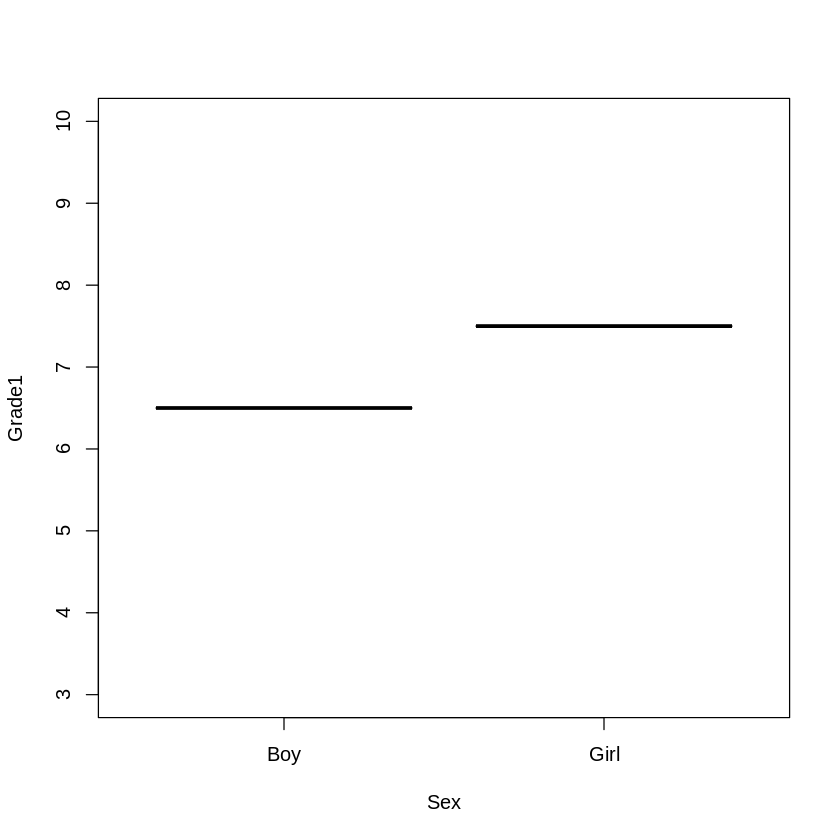

In [1]:
set.seed(524)

# Sex factor (Boy, Girl)
Sex <- gl(2,525, labels = c("Boy", "Girl"))

# Numerical mean scores by sex
SexN <- rep(c(6.5, 7.5), each = 525)

# Grade based only on sex (simple t-test situation)
Grade1 <- SexN

# Visualize difference between Boys and Girls
# Label of 5 classes and 7 school 7*5 objects
plot(Grade1 ~ Sex, ylim = c(3,10))


### 📊 Interpretation

* Girls mean = 7.5
* Boys mean = 6.5

This is equivalent to a two-sample t-test model

#### 📌 PART 2: DEFINE SCHOOL (FIRST LEVEL OF NESTING)

Created a nested structures of factor level means.

Factor school: 7 school with 5 classes of 15 boys and 15 girls each.


In [2]:
# 7 schools, each with 5 classes
School <- gl(7, 5, labels = LETTERS[1:7])

# Repeat for 15 students per gender
SchoolF <- rep(School, each = 15, times = 2)

Means Schools: Every schools has a certain average deviations from the gender score.

In [3]:
# Random deviation for each school
AV_School <- round(rnorm(7,0,0.5),1)

# Expand school means to student level
SchoolN <- rep(AV_School, each = 75, times = 2)

### 📊 Interpretation

Each school has its own average deviation:

$u_School​∼N(0,0.5^2)$

#### 📌 PART 3: DEFINE CLASS (NESTED WITHIN SCHOOL)

Factor Class: Every class in every school has its own average score.

In [4]:
# 5 classes per school (total 35 classes)
Class  <- gl(5, 1, length = 7*5, labels = letters[1:5])     # label 5 Classes in 7 school

ClassF <- rep(Class, each = 15, times = 2)                # 5 classes each 15 girls in 7 schools times 2 for boys


Means Classes: Every Class has its own deviation from the school deviation of the gender score.

In [5]:
# Random deviation for each class (35 classes)
Class <- round(rnorm(35, 0, 0.2),1)              # 35 class averages

ClassN <- rep(Class, each = 15, times = 2)          # 35 class averages for 15 girls and boys

### 📊 Interpretation

Each class has deviation from its school:

$u_{Class(School)} ​∼ N(0,0.2^2)$

#### 📌 PART 4: CREATE NESTED STRUCTURE

Sum of deviation of Gender means and create an unique class identifier as a combination of School and Class label.

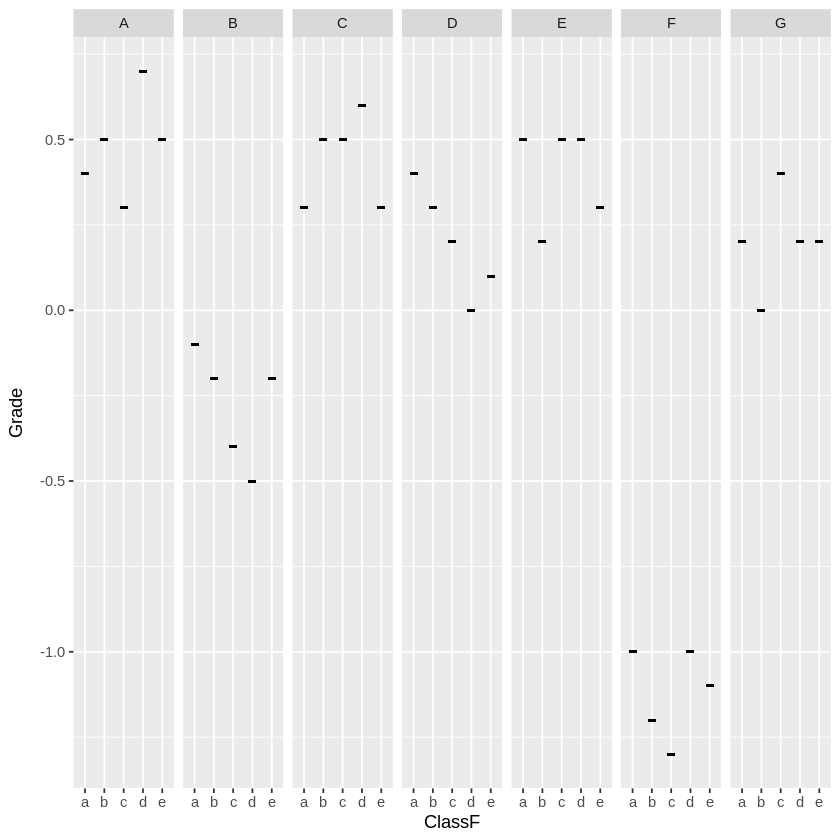

In [6]:
# Load ggplot2
library(ggplot2)

# Combine deviations
Grade <- SchoolN + ClassN

# Create unique class identifier nested within school
ClassID <- interaction(SchoolF, ClassF)

Nested <- data.frame(Grade, SchoolF, SchoolN, ClassF, ClassN, ClassID)

# Visualize nested structure
ggplot(Nested, aes(ClassF, Grade))+
  geom_point(pch = "-", size = 6) +
  facet_grid(. ~ SchoolF)

### 📊 Interpretation

* X‑axis (ClassF): Each tick represents a class within a school.

* Y‑axis (Grade): The plotted values are the grades associated with each class.

* Points (shape = "-"): Each class’s grade is displayed as a minus‑sign marker, sized large for visibility.

* Facets (. ~ SchoolF): The plot is split into columns, one for each school. This allows you to compare class‑level grade distributions side by side across schools.

Graph shows:
* Within each school’s panel, you can observe how grades differ across classes.
* The vertical spread of points indicates variability in grades between classes inside the same school.
* Comparing across panels shows whether some schools tend to have higher or lower grades overall, or whether grade variability differs by school.
* Classes differ within schools
* Every class belongs to exactly one school
* This confirms nested structure

To see the nested structure better.

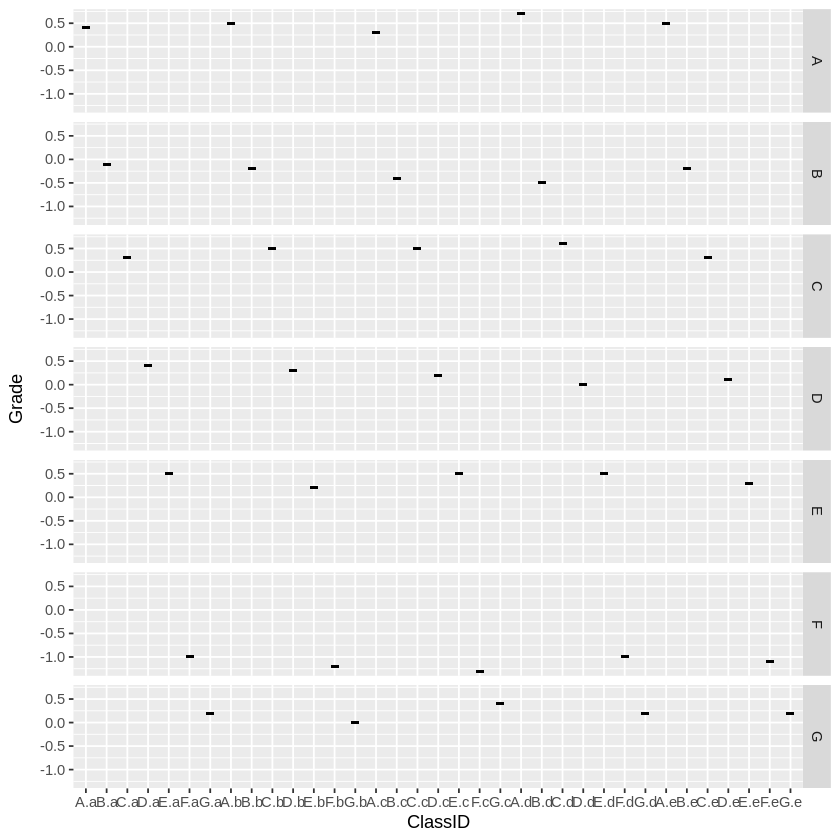

In [7]:
# Plot by ClassID, faceted by SchoolF
ggplot(Nested, aes(ClassID, Grade))+
  geom_point(pch = "-", size = 6) +
  facet_grid( SchoolF ~ .)

### 📊 Interpretation
* X‑axis (ClassID): Each point corresponds to a unique combination of school and class, created by interaction(SchoolF, ClassF). This means every class within a school is treated as a distinct category.

* Y‑axis (Grade): The plotted values represent the grade outcome for each class.

* Facets (SchoolF ~ .): The plot is split into separate rows, one per school. This makes it easy to compare grade distributions across classes within the same school, while keeping schools visually separated.

* Points (shape = "-"): Each class’s grade is shown as a point, styled with a minus sign symbol. The relatively large size (size = 6) makes them stand out clearly.

Graph shows:
* Within each school panel, you’ll see how grades vary across different classes (ClassID).

* Differences in vertical spread indicate variability in grades between classes.

* Comparing across facets shows whether some schools tend to have higher or lower grades overall.

#### 📌 PART 5: FULL MODEL (ADD ALL VARIANCE COMPONENTS)

Final grade consists of:
* Sex effect
* School variance
* Class variance
* Individual residual error

Combine all elements of the model:

Finalgrade = effect of Sex + variance due to schools + variance to classes + variance due to individual boys and girls


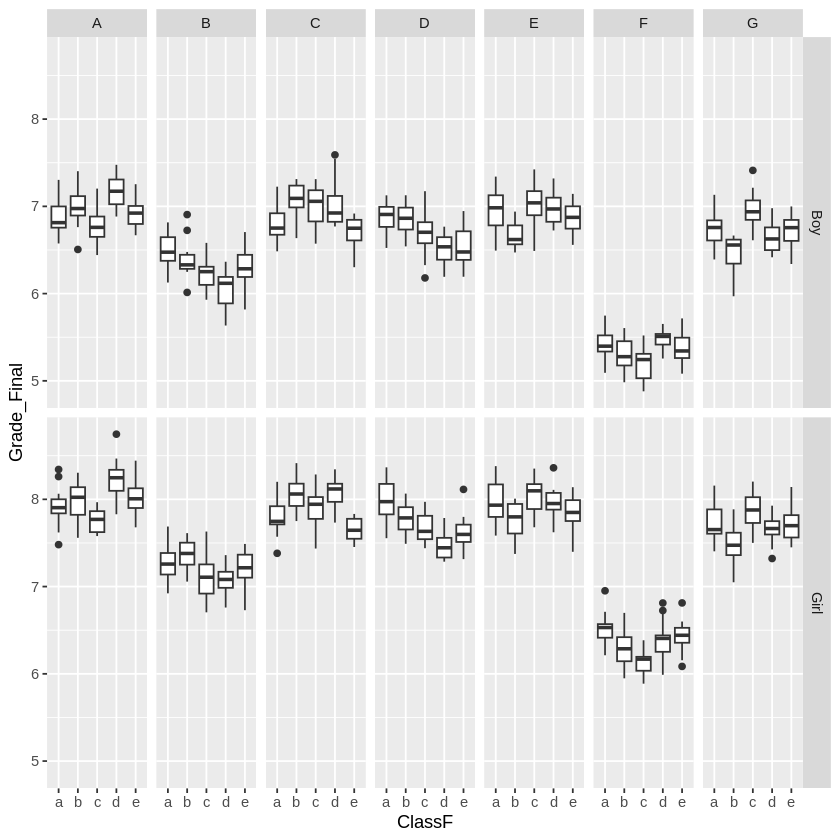

In [8]:
# Load required package
library(ggplot2)

# Simulate final grades with nested structure
# set.seed(123)  # for reproducibility
Grade_Final <- SexN + SchoolN + ClassN + rnorm(1050, 0, 0.2)

# Build data frame with relevant factors
NestedF <- data.frame(Grade_Final, Sex, SchoolF, ClassF, ClassID)

# Visualize nested structure with boxplots
ggplot(NestedF, aes(ClassF, Grade_Final))+ geom_boxplot() + facet_grid(Sex ~ SchoolF)


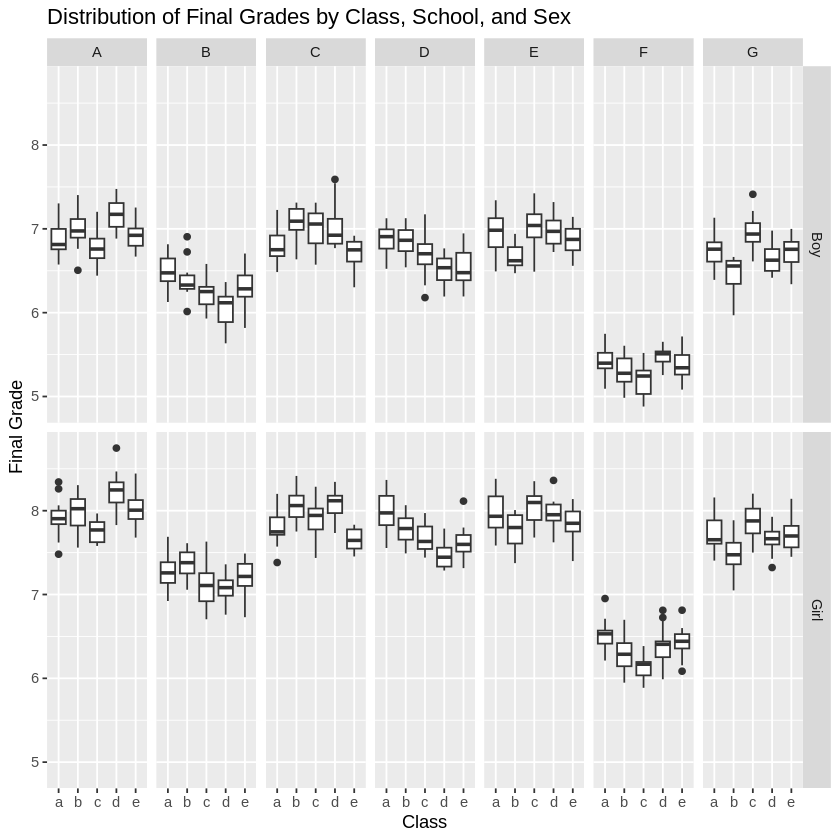

In [9]:
ggplot(NestedF, aes(ClassF, Grade_Final))+
  geom_boxplot() +
  facet_grid(Sex ~ SchoolF) +
  labs(title = "Distribution of Final Grades by Class, School, and Sex",
    x = "Class", y = "Final Grade")

### 📊 Interpretation
* X‑axis (ClassF): Each tick represents a class within a school.
* Y‑axis (Grade_Final): The distribution of final grades for each class.
* Boxplots: Each box summarizes the grade distribution in a class:
   * The horizontal line inside the box is the median grade.
   * The box edges show the interquartile range (middle 50% of grades).
   * Whiskers and any points beyond them highlight variability and possible outliers.
* Facets (Sex ~ SchoolF): The plot is split into a grid:
   * Columns represent different schools (SchoolF).
   * Rows represent sex (Sex).
   * This layout makes it easy to compare grade distributions across classes within each school, separately for male and female students.


Graph shows:
* Within each school column, you can compare how grades differ across classes.
* Between sexes (rows), you can see whether grade distributions shift — for example, whether one sex tends to have higher medians or more variability.
* Across schools (columns), you can assess whether some schools show consistently higher or lower grades overall.

#### 📌 PART 6: ANALYSE USING MIXED MODEL (Nested ANOVA)

📊 MODEL STRUCTURE

$Y_{ijkl}​ = μ + β_1 ​Sex + u_{School}​ + u_{Class(School)}​ + ε$

Where:

$u_{School} ​∼ N(0,σ_{School}^2)​$

$u_{Class(School)} ​∼ N(0,σ_{Class}^2)​$

$ε ∼ N(0,σ^2)$


In [10]:
# Install lme4 if not already installed
#install.packages("lme4")

In [11]:
# Load required package
library(lme4)

# Fit mixed-effects model
Model <- lmer(
  Grade_Final ~ Sex +                # fixed effect for sex
    (1 | SchoolF) +                  # random intercept for schools
    (1 | SchoolF:ClassID),           # random intercept for classes nested within schools
  data = NestedF)

# Inspect model summary
summary(Model)


Loading required package: Matrix



Linear mixed model fit by REML ['lmerMod']
Formula: Grade_Final ~ Sex + (1 | SchoolF) + (1 | SchoolF:ClassID)
   Data: NestedF

REML criterion at convergence: -275.5

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.69689 -0.68142  0.00585  0.65207  2.80713 

Random effects:
 Groups          Name        Variance Std.Dev.
 SchoolF:ClassID (Intercept) 0.02195  0.1482  
 SchoolF         (Intercept) 0.32925  0.5738  
 Residual                    0.03954  0.1989  
Number of obs: 1050, groups:  SchoolF:ClassID, 35; SchoolF, 7

Fixed effects:
            Estimate Std. Error t value
(Intercept)  6.54544    0.21849   29.96
SexGirl      0.98981    0.01227   80.64

Correlation of Fixed Effects:
        (Intr)
SexGirl -0.028

### 📊 Interpretation


🔹 Fixed Effect: Sex

If output shows: SexGirl  -0.035

Interpretation:
* Estimated difference between Girls and Boys ≈ 0
* Very small effect
* After accounting for school and class variability, sex difference is negligible

🔹 Random Effects

Variance components show:
* School-level variation
* Class-within-school variation
* Residual variation

####  📌 PART 7: VISUALIZE RANDOM EFFECTS

$`SchoolF:ClassID`

$SchoolF


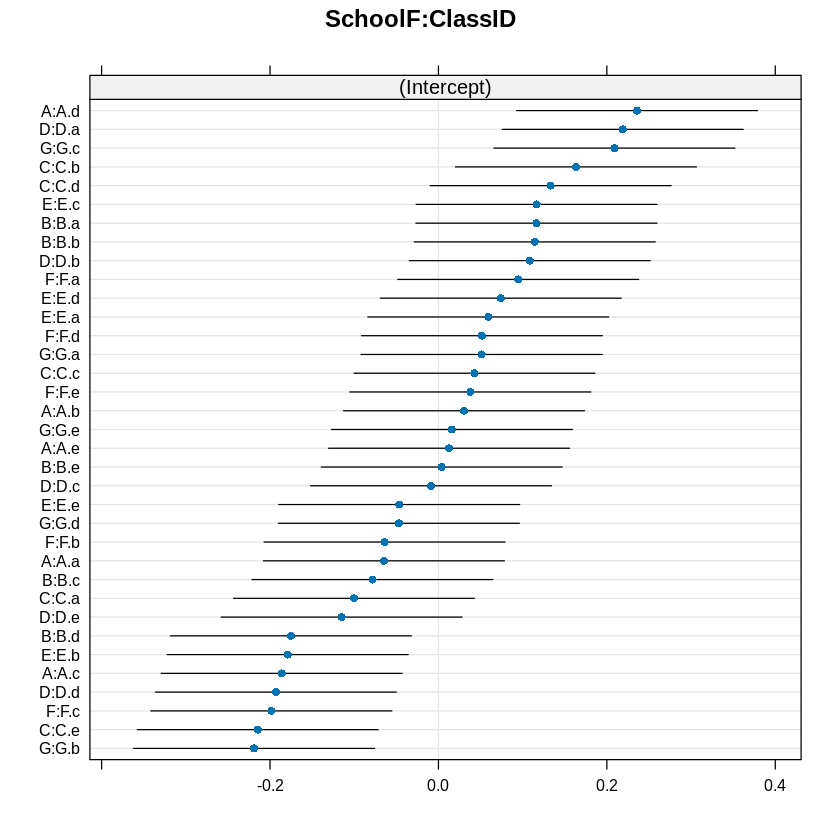

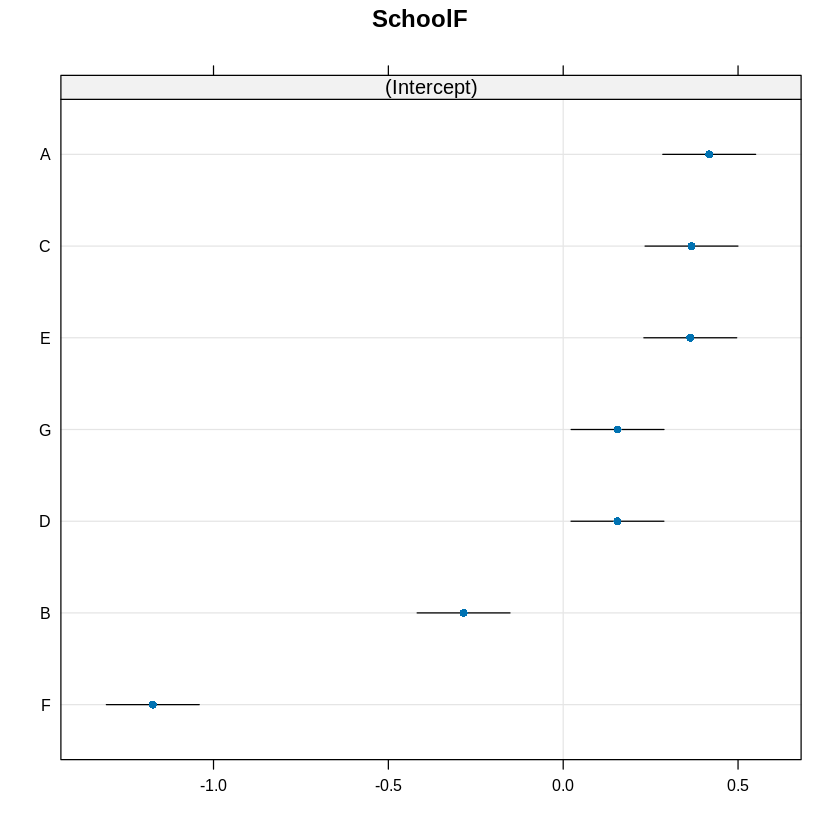

In [12]:
# Load lattice (only once per session)
library(lattice)

# Dotplot of random effects from Model1
dotplot(ranef(Model, condVar = TRUE))


### 📊 Interpretation

* Displays deviations for schools
* Displays deviations for classes nested within schools
* Confidence intervals indicate uncertainty
* Confirms hierarchical variability

### Combined R Code

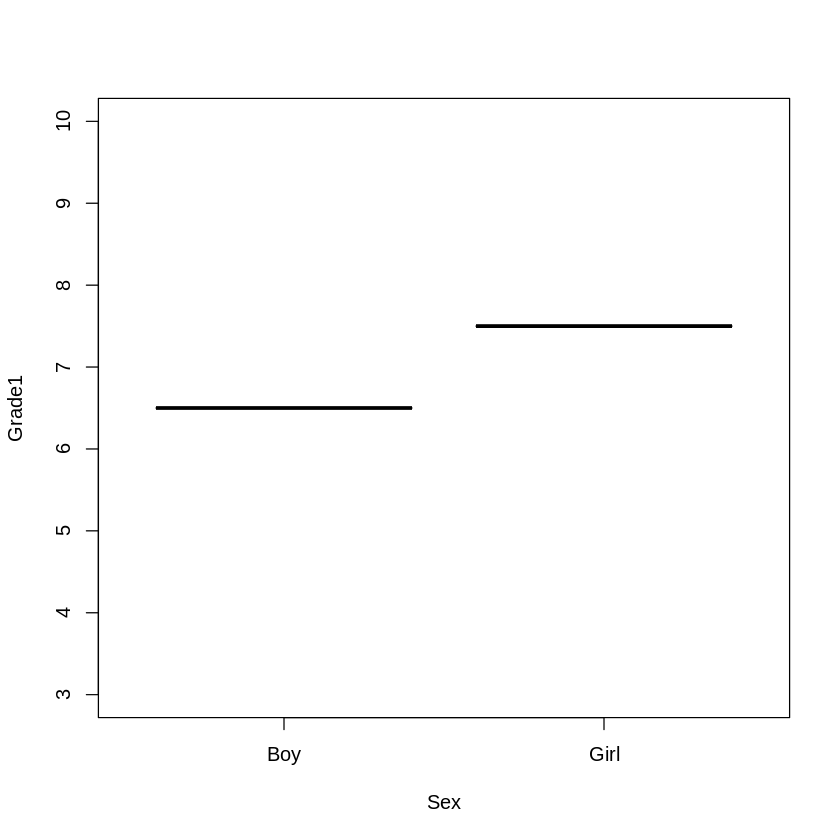

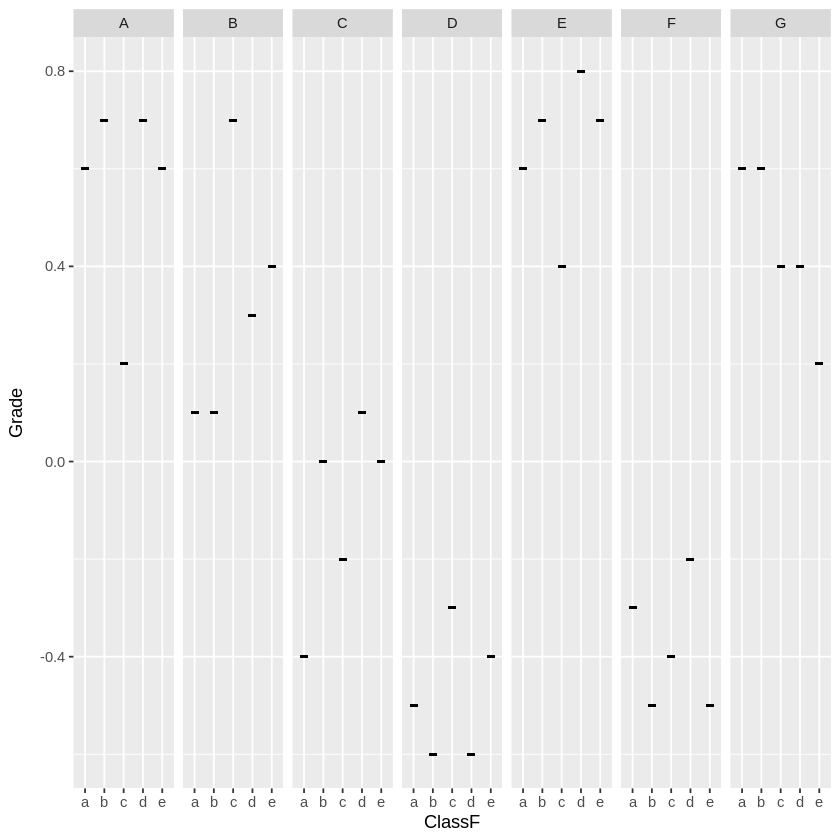

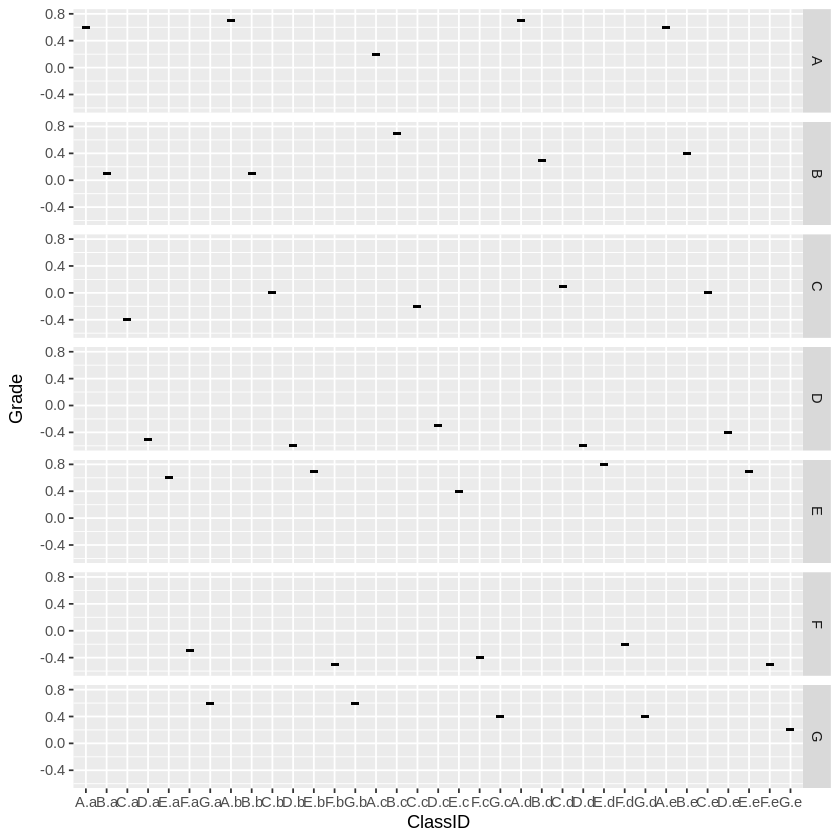

Linear mixed model fit by REML ['lmerMod']
Formula: Grade_Final ~ Sex + (1 | SchoolF) + (1 | SchoolF:ClassID)
   Data: NestedF

REML criterion at convergence: -265.6

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.69742 -0.67172  0.00207  0.64832  2.76034 

Random effects:
 Groups          Name        Variance Std.Dev.
 SchoolF:ClassID (Intercept) 0.03897  0.1974  
 SchoolF         (Intercept) 0.21068  0.4590  
 Residual                    0.03943  0.1986  
Number of obs: 1050, groups:  SchoolF:ClassID, 35; SchoolF, 7

Fixed effects:
            Estimate Std. Error t value
(Intercept)  6.64060    0.17688   37.54
SexGirl      0.99142    0.01226   80.89

Correlation of Fixed Effects:
        (Intr)
SexGirl -0.035

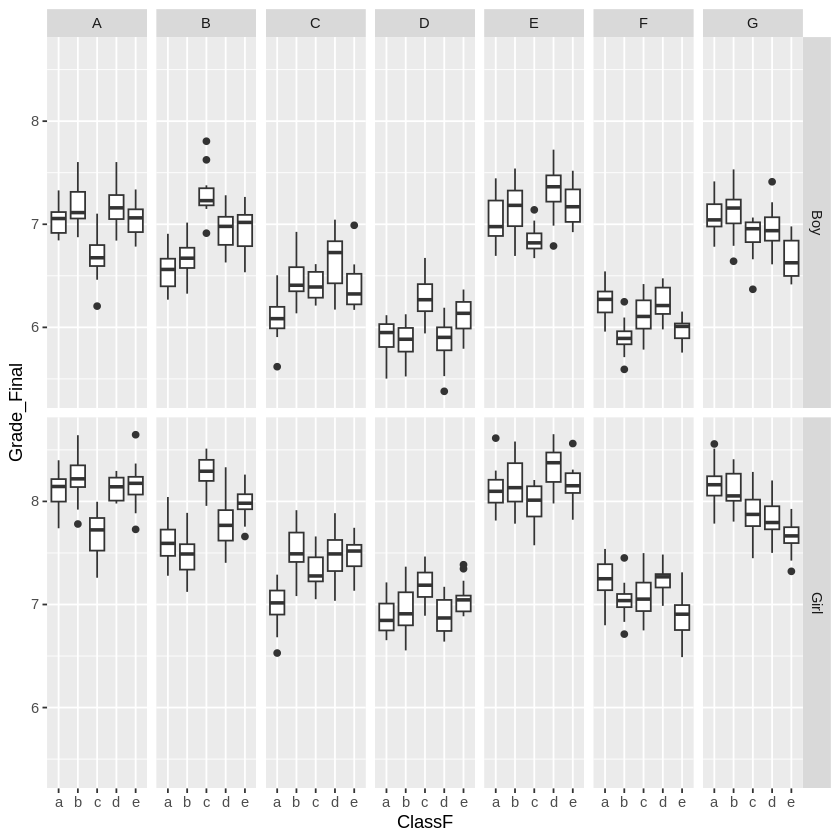

$`SchoolF:ClassID`

$SchoolF


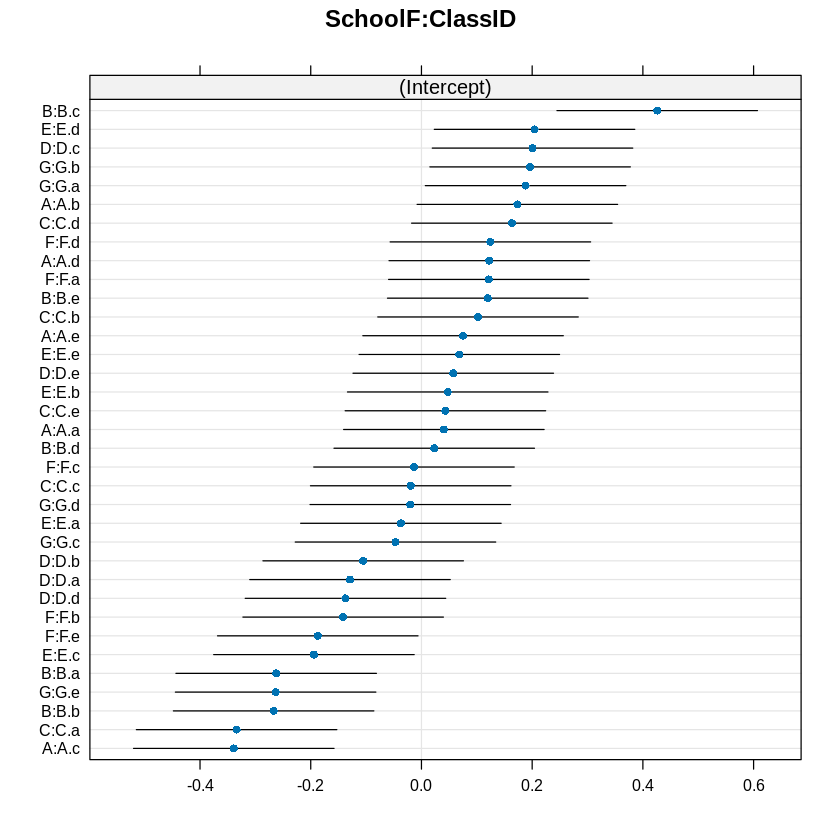

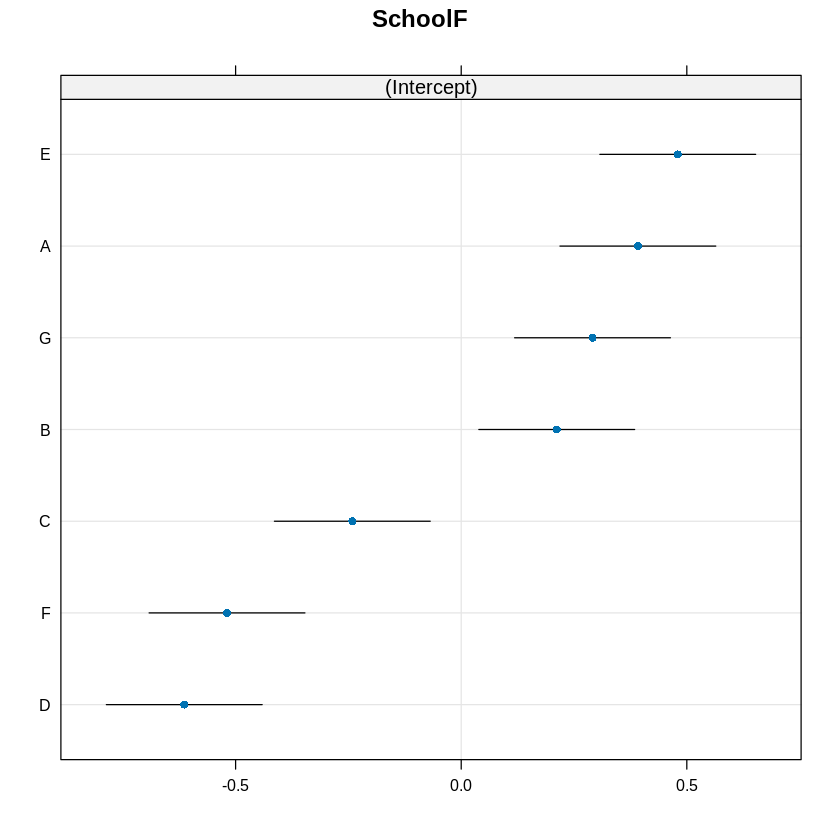

In [13]:
set.seed(524)
Sex<- gl(2,525, labels = c("Boy", "Girl"))
SexN <- rep(c(6.5, 7.5), each = 525)
Grade1 <- SexN
plot(Grade1 ~ Sex, ylim = c(3,10))
School <- gl(7, 5, labels = LETTERS[1:7])    # Label of 5 classes and 7 school 7*5 objects
SchoolF <- rep(School, each = 15, times = 2)  # with 15 students per 2 gender types
AV_School <- round(rnorm(7,0,0.5),1)              # Random number of 7 average scores.
SchoolN <- rep(AV_School, each = 75, times = 2)   # every school has 75 students having a average school score and two gender types.
Class  <- gl(5, 1, length = 7*5, labels = letters[1:5]) # label 5 Classes in 7 school
ClassF <- rep(Class, each = 15, times = 2) # 5 classes each 15 girls in 7 schools times 2 for boys
Class <- round(rnorm(35, 0, 0.2),1)  # 35 class averages
ClassN <- rep(Class, each = 15, times = 2) # 35 class averages for 15 girls and boys
Grade <- SchoolN + ClassN
ClassID <- interaction(SchoolF, ClassF)
Nested <- data.frame(Grade, SchoolF, SchoolN, ClassF, ClassN, ClassID)
ggplot(Nested, aes(ClassF, Grade))+ geom_point(pch = "-", size = 6) + facet_grid(. ~ SchoolF)
ggplot(Nested, aes(ClassID, Grade))+ geom_point(pch = "-", size = 6) + facet_grid( SchoolF ~ .)
Grade_Final <- SexN + SchoolN + ClassN + rnorm(1050, 0, 0.2)
NestedF <- data.frame(Grade_Final, Sex, SchoolF, ClassF, ClassID)
ggplot(NestedF, aes(ClassF, Grade_Final))+ geom_boxplot() + facet_grid(Sex ~ SchoolF)
library(lme4)
Model <- lmer(Grade_Final ~ Sex + (1|SchoolF) + (1|SchoolF:ClassID), data = NestedF)
summary(Model)
library(lattice)
dotplot(ranef(Model, condVar = TRUE))

<div class="alert alert-block alert-info" style="margin-top: 20px">
    
### THANK YOU ...! 

__Ms.MRUNALINI (Data Science Trainer)__
📧 mrunalini0107@gmail.com
📍 Mumbai–400095